In [24]:
import numpy as np
import pandas as pd
from sklearn import datasets
iris = datasets.load_iris()
x_sepal = iris.data[:,[0,1]]
x_petal = iris.data[:,[2,3]]
y = iris.target

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x_train_sepal,x_test_sepal,y_train_sepal,y_test_sepal = train_test_split(x_sepal,y,test_size=0.2,random_state=0)
print("Number of training samples for sepal:",len(x_train_sepal))
print("Number of testing samples for sepal:",len(x_test_sepal))
scaler = StandardScaler() 
x_train_sepal = scaler.fit_transform(x_train_sepal)
x_test_sepal = scaler.transform(x_test_sepal)
x_combined_sepal = np.vstack((x_train_sepal,x_test_sepal))
y_combined_sepal = np.hstack((y_train_sepal,y_test_sepal))

Number of training samples for sepal: 120
Number of testing samples for sepal: 30


In [25]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(penalty = 'l2',C=10) # C is the regularization parameter, smaller C means stronger regularization.
lr.fit(x_train_sepal,y_train_sepal)
score = lr.score(x_test_sepal,y_test_sepal)
print("Accuracy of logistic regression model on sepal data: {:.2f}%".format(score*100))

Accuracy of logistic regression model on sepal data: 73.33%


In [26]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap # This is used to create a custom colormap for the plot.
def plot_decision_regions(x,y,classifier,test_idx = None,resolution = 0.02):
    # setup marker generator and color map first.
    markers = ('o','x','v')
    colors = ('red','blue','lightgreen')
    colormap = ListedColormap(colors[:len(np.unique(y))])
    x1_min,x1_max = x[:,0].min()-1,x[:,0].max()+1
    x2_min,x2_max = x[:,1].min()-1,x[:,1].max()+1
    xx1,xx2 = np.meshgrid(np.arange(x1_min,x1_max,resolution),np.arange(x2_min,x2_max,resolution))
    # This creates a grid of points over the feature space, which will be used to visualize the decision boundaries of the classifier.
    z = classifier.predict(np.array([xx1.ravel(),xx2.ravel()]).T)
    z = z.reshape(xx1.shape)
    plt.contour(xx1,xx2,z,alpha = 0.4,cmap = colormap)
    plt.xlim(xx1.min(),xx1.max())
    plt.ylim(xx2.min(),xx2.max())
    x_test,y_test = x[test_idx,:],y[test_idx]
    for idx,cl in enumerate(np.unique(y)):
        plt.scatter(x=x[y==cl,0],y=x[y==cl,1],alpha = 0.8,c=colormap(idx),marker = markers[idx],label = cl)
        

/var/folders/fr/r6xzz0f12nn0tkt1mmf1wqk00000gn/T/ipykernel_68313/1983096056.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x=x[y==cl,0],y=x[y==cl,1],alpha = 0.8,c=colormap(idx),marker = markers[idx],label = cl)
/var/folders/fr/r6xzz0f12nn0tkt1mmf1wqk00000gn/T/ipykernel_68313/1983096056.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x=x[y==cl,0],y=x[y==cl,1],alpha = 0.8,c=colormap(idx),mark

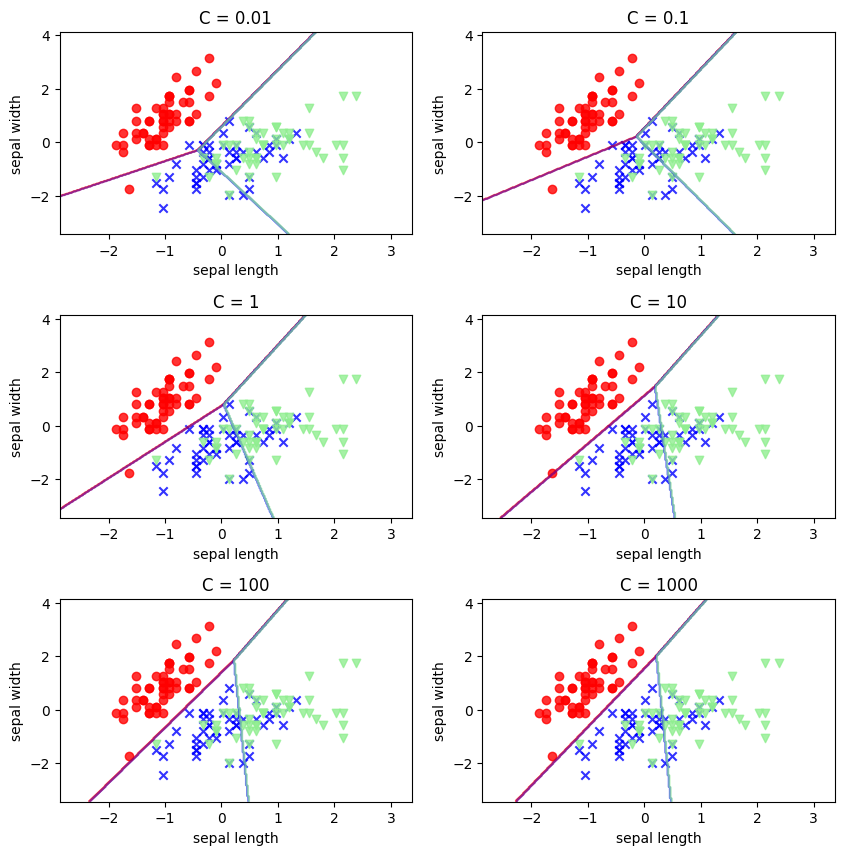

In [27]:
from sklearn.metrics import accuracy_score
c_param = [0.01,0.1,1,10,100,1000]
sepal_acc_table = pd.DataFrame(columns = ['C_parameter','Accuracy'])
sepal_acc_table['C_parameter'] = c_param
plt.figure(figsize = (10,10)) #This sets the size of the figure to 10 inches by 10 inches.
j = 0
for i in c_param:
    lr = LogisticRegression(penalty='l2',C=i,random_state = 0)
    lr.fit(x_train_sepal,y_train_sepal)
    y_pred_sepal = lr.predict(x_test_sepal)
    sepal_acc_table.iloc[j,1] = accuracy_score(y_test_sepal,y_pred_sepal)
    j+=1
    plt.subplot(3,2,j)
    plt.subplots_adjust(hspace=0.4)
    plot_decision_regions(x=x_combined_sepal,y = y_combined_sepal,classifier=lr,test_idx=range(0,150))
    plt.xlabel('sepal length')
    plt.ylabel('sepal width')
    plt.title('C = %s'%i)